<a href="https://colab.research.google.com/github/FrancescaMicu/3DUPB_Computer_Vision/blob/main/proiect3DUPB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import json, random, copy, re, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42)

In [6]:
# instalare api-uri
!pip install transformers accelerate bitsandbytes matplotlib

#
GRID_W, GRID_H = 16, 16
# codificarea hartii
# Bird -> zona blocata
# Normal Ladder -> pas inainte
# Start -> baza de inceput
# Exit -> Iesirea
# Beetle -> inamicul care trebuie ocolit cu orice pret (altfel se pierde jocul)
# Portal -> te teleporteaza la cealalta iesire a portalului
# Vines -> pas inainte dublu
# Broken Ladder -> coborare cu un rand mai jos fortata
# Golden Ladder -> trebuie trecut prin acest loc pe traseul spre end
TILE = {
    0:('.','#1a1a2e','Bird'),
    1:('N','#dfe6e9','Normal Ladder'),
    2:('S','#00b894','Start'),
    3:('E','#d63031','Exit'),
    4:('K','#f39c12','Beetle'),
    5:('P','#8e44ad','Portal'),
    6:('V','#c0392b','Vines'),
    7:('B','#f1c40f','Broken Ladder'),
    8:('+', '#ffd700', 'Golden Ladder')
}

PASSABLE = {1, 2, 3, 4, 5, 6, 7, 8}
COLORS = {k:v[1] for k, v in TILE.items()}
ASCII_MAP = {v[0]:k for k, v in TILE.items()}
VALID_CHARS = set(ASCII_MAP.keys())
print(VALID_CHARS)

print('✅ Config OK — Joc: Climb the Tower — Grid:', GRID_W, 'x', GRID_H)

{'P', 'E', '+', 'S', 'V', 'K', 'N', 'B', '.'}
✅ Config OK — Joc: Climb the Tower — Grid: 16 x 16


In [ ]:
# descarcam LLM-ul

# conectare cu google colab
from google.colab import drive
from huggingface_hub import snapshot_download

drive.mount('/content/drive')

snapshot_download(
    repo_id="HuggingFaceTB/SmolLM2-1.7B-Instruct",
    local_dir="/content/drive/MyDrive/models/smollm2",
    ignore_patterns=["*.msgpack","*.h5","flax_*"],
)

print("✅ Model salvat în Drive!")

In [7]:
# incarcare din drive
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from google.colab import drive

drive.mount('/content/drive')
MODEL_ID = "/content/drive/MyDrive/models/smollm2"

print(f'🔄 Încărcare model din Drive...')
print(f'   GPU: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb, device_map='auto')
model.eval()
print('✅ Model încărcat din Drive!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Încărcare model din Drive...
   GPU: True
   VRAM: 15.6 GB


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

✅ Model încărcat din Drive!


In [8]:
# generare nivel folosind smollm2

# pregatirea promptului
SYSTEM = """You are a game level designer. Generate a tree-climbing level as ASCII art

Characters: . = Bird, N = Normal Ladder, S = Start, E = Exit, K = Beetle, P = Portal, V = Vines, B = Broken Ladder, G = Golden Ladder

RULES:
- Exactly 1 S and 1 E
- The start S must always be in the last row
- The exit E must always be in the first row
- The bird . has the same purpose as a wall
- The beetle K is the enemy, if you step on it the game is over
- If there are portals P, there must always be 2
- One vine gives you a boost so you can skip a row upwards
- The majority of the ladders (N and B) must be connected to form a path upwards, so you can go up on the ladder
- There can be ladders that are connected horizontaly, so you can go left or right on the ladder
- The only way to win the game is to find a path to pass through that respects the rules, there must be a way to get from start to end
- Output ONLY the 16 lines with 16 characters each and no other explanation
- You must find a path to the exit E through all the Golden Ladders +

"""
USER = """....NN..EB..NNN.
..NNNNNNNN+NNNN.
..NNNB...NNNN..N
..NNNNNNNNNNN..N
.N.NN..NN.BNN.NN
.N+NNNNN...BN..N
..NNNNNNNNNNN..N
..N.N..NNN.N.NNN
..P.N.NN.NNN.NN.
..NNNNNNN...NN..
.N.N.N.BN.NN.NN.
.NNN.N.KN..NN...
..NNKNNNNN.NN...
..NNN.NNN.NNNN..
..PN...NB.N..NNN
..SNNNNNNNN...NN

Modify this level to make it more interesting. Output ONLY the 16 lines, with no other text."""

def calling_llm(system, user, temp = 0.4, max_new = 400):
  msgs = [{'role':'system','content':system}, {'role':'user','content':user}]
  txt  = tokenizer.apply_chat_template(msgs, tokenize = False, add_generation_prompt = True)
  inp  = tokenizer(txt, return_tensors='pt').to(model.device)
  with torch.no_grad():
      out = model.generate(**inp, max_new_tokens = max_new, temperature=temp,
              do_sample=True, top_p=0.9,
              pad_token_id=tokenizer.eos_token_id)
  return tokenizer.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)

def parse_ascii_permisive(resp):
  lines = []

  # harta trebuie sa aiba exact GRID_W caractere
  for raw_line in resp.strip().split('\n'):
    line = raw_line.strip()
    if not line or len(line) < GRID_W / 4:
      continue
    cleaned = ''.join(c if c in VALID_CHARS else '.' for c in line)
    if len(cleaned) < GRID_W / 2:
      continue
    if len(cleaned) > GRID_W:
      cleaned = cleaned[:GRID_W]

    if len(cleaned) < GRID_W:
      pad = '.'
      cleaned = cleaned + pad * (GRID_W - len(cleaned))

    lines.append([ASCII_MAP.get(c, 1) for c in cleaned])
    if len(lines) == GRID_H:
      break

  # harta are prea putin linii
  while len(lines) < GRID_H:
    lines.append([0] * GRID_W)

  # ne asiguram ca harta are exact cate linii are nevoie
  return lines[:GRID_H]

print('✅ Functii de apel llm si de parsare definite')



✅ Functii de apel llm si de parsare definite


In [44]:
from collections import deque

# functii de parsare
def find_tiles(g, tid):
  hits = []
  for r, row in enumerate(g):
    for c, t in enumerate(row):
      if t == tid:
        hits.append((r,c))
  return hits

def find_tile(g, tid):
    for r, row in enumerate(g):
        for c, t in enumerate(row):
            if t == tid:
              return(r,c)
    return None

# functie de validare prin bfs
def bfs(g, start, goal, passable, portals):
  if not start or not goal:
    return False, 0
  if start == goal:
    return True, 0

  q = deque([(start, 0)])
  vis = {start}

  while q:
    (r, c), d = q.popleft()

    # broken ladder forteaza miscarea in jos
    if g[r][c] == 7:
      moves = [(1, 0)]
    # vine forteaza miscarea cu 2 casute mai sus
    elif g[r][c] == 6:
      moves = [(-2, 0)]
    else:
      moves = [(-1, 0), (0, -1), (0, 1)]

    neighbors = []

    for dr, dc in moves:
      nr, nc = r + dr, c + dc

      neighbors.append((nr, nc))

    # tile-ul este un portal
    if (r, c) in portals and len(portals) == 2:
      other_portal = portals[1] if portals[0] == (r, c) else portals[0]
      neighbors.append(other_portal)

    for nr, nc in neighbors:
      if not(0 <= nr < GRID_H and 0 <= nc < GRID_W):
        continue
      if (nr, nc) in vis:
        continue

      if (nr, nc) == goal:
        return True, d + 1

      if g[nr][nc] in passable:
        vis.add((nr, nc))
        q.append(((nr, nc), d + 1))

  return False, 0

# functii de reparare a hartii
def fix_grid(g):
    # ==========================================
    # 1. Conectarea scărilor pe verticală
    # ==========================================
    for c in range(GRID_W):
        ladders = []
        for r in range(GRID_H):
            if g[r][c] in [1, 6, 7, 8]:
                ladders.append(r)

        if len(ladders) >= 2:
            for k in range(len(ladders) - 1):
                r_up = ladders[k]
                r_down = ladders[k + 1]
                if r_down - r_up <= 4:
                    for r_mid in range(r_up + 1, r_down):
                        if g[r_mid][c] == 0:
                            g[r_mid][c] = 1

    # ==========================================
    # 2. Curățare și plasare START (2) și EXIT (3)
    # ==========================================
    for r in range(GRID_H):
        for c in range(GRID_W):
            if g[r][c] in (2, 3):
                g[r][c] = 1

    start_c = (GRID_W - 5) // 2       # Coloana 5 dacă W=16
    exit_c = start_c + 5              # Coloana 10 dacă W=16

    g[GRID_H - 1][start_c] = 2        # Start pe ultimul rând
    g[0][exit_c] = 3                  # Exit pe primul rând

    # ==========================================
    # 3. Corectare Portaluri (5)
    # ==========================================
    portals = find_tiles(g, 5)
    if len(portals) > 2:
        for r, c in portals[2:]:
            g[r][c] = 1
    elif len(portals) == 1:
        pr, pc = portals[0]
        g[pr][pc] = 1

    # ==========================================
    # 4. Forțare EXACT 2 Golden Ladders (8) la minim 5 COLOANE distanță
    # ==========================================
    golden = find_tiles(g, 8)

    # Verificăm dacă cele existente sunt la minim 5 coloane distanță
    valid_existing = (
        len(golden) == 2
        and abs(golden[0][1] - golden[1][1]) >= 5
    )

    if not valid_existing:
        # Resetăm scările de aur existente
        for r, c in golden:
            g[r][c] = 1

        start_pt = (GRID_H - 1, start_c)
        goal_pt = (0, exit_c)
        passables = {1, 2, 3, 5, 6, 7}

        q = deque([[start_pt]])
        vis = {start_pt}
        path = []
        active_portals = find_tiles(g, 5)

        while q:
            p = q.popleft()
            curr = p[-1]
            if curr == goal_pt:
                path = p
                break

            r, c = curr
            moves = [(-1, 0), (0, -1), (0, 1)]
            if g[r][c] == 7:
                moves = [(1, 0)]

            neighbors = []
            for dr, dc in moves:
                nr, nc = r + dr, c + dc
                if g[r][c] == 6 and dr == -1:
                    nr = r - 2
                neighbors.append((nr, nc))

            if (r, c) in active_portals and len(active_portals) == 2:
                other = active_portals[1] if active_portals[0] == (r, c) else active_portals[0]
                neighbors.append(other)

            for nr, nc in neighbors:
                if 0 <= nr < GRID_H and 0 <= nc < GRID_W and (nr, nc) not in vis and g[nr][nc] in passables:
                    vis.add((nr, nc))
                    q.append(p + [(nr, nc)])

        # Plasare pe path la minim 5 coloane distanță
        if len(path) >= 6:
            # Primul checkpoint: în prima treime a drumului
            idx1 = max(1, len(path) // 4)
            pos1 = path[idx1]
            if pos1 in (start_pt, goal_pt):
                pos1 = path[1]

            pos2 = None
            # Căutăm al doilea checkpoint pornind dinspre final cu diferență de coloană >= 5
            for idx2 in range(len(path) - 2, 0, -1):
                cand = path[idx2]
                if cand not in (start_pt, goal_pt, pos1):
                    if abs(cand[1] - pos1[1]) >= 5:
                        pos2 = cand
                        break

            # Fallback dacă traseul nu oferă o lățime de 5 coloane:
            # alegem celula cu distanța orizontală maximă posibilă față de pos1
            if pos2 is None:
                best_cand = None
                max_col_diff = -1
                for cand in path[1:-1]:
                    if cand not in (start_pt, goal_pt, pos1):
                        col_diff = abs(cand[1] - pos1[1])
                        if col_diff > max_col_diff:
                            max_col_diff = col_diff
                            best_cand = cand
                pos2 = best_cand

            g[pos1[0]][pos1[1]] = 8
            if pos2 and pos2 != pos1:
                g[pos2[0]][pos2[1]] = 8

    # ==========================================
    # 5. Neutralizare Insule Izolate (Transformare în Birds / Zid = 0)
    # ==========================================
    start_pos = (GRID_H - 1, start_c)
    q = [start_pos]
    vis = {start_pos}
    active_portals = find_tiles(g, 5)

    while q:
        curr_r, curr_c = q.pop(0)

        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = curr_r + dr, curr_c + dc
            if 0 <= nr < GRID_H and 0 <= nc < GRID_W:
                if (nr, nc) not in vis and g[nr][nc] != 0:
                    vis.add((nr, nc))
                    q.append((nr, nc))

        # Tranzitare prin portaluri
        if g[curr_r][curr_c] == 5 and len(active_portals) == 2:
            other = active_portals[1] if active_portals[0] == (curr_r, curr_c) else active_portals[0]
            if other not in vis:
                vis.add(other)
                q.append(other)

    # Orice celulă care NU a fost atinsă de Flood Fill devine Bird (0)
    for r in range(GRID_H):
        for c in range(GRID_W):
            if (r, c) not in vis:
                g[r][c] = 0  # Curăță orice alt element (inamici/scări/capcane izolate)

    return g
    for r in range(GRID_H):
        for c in range(GRID_W):
            if g[r][c] != 0 and (r, c) not in vis:
                g[r][c] = 0

    return g

# functii de testare
def validate(g):
  res = {'valid' : False, 'issues' : [], 'metrics' : {}}
  s = find_tile(g, 2)
  ex = find_tile(g, 3)
  portals = find_tiles(g, 5)
  golden_ladders = find_tiles(g, 8)

  # cautam existenta startului
  if not s:
    res['issues'].append('Lipsă START')
    return res
  elif s[0] != GRID_H - 1:
    res['issues'].append(f'START nu e pe ultimul rând (găsit pe {s[0]})')
    return res

  # cautam existenta iesirii
  if not ex:
    res['issues'].append('Lipsă EXIT')
    return res
  elif ex[0] != 0:
    res['issues'].append(f'EXIT nu e pe primul rând (găsit pe {ex[0]})')
    return res

  # verificam logica de portaluri
  if len(portals) != 2 and len(portals) != 0:
    res['issues'].append(f'Număr incorect de portaluri: {len(portals)} (trebuie 0 sau 2)')
    return res

  # verificare distanta fixa dintre Start si Exit
  if abs(s[1] - ex[1]) != 5:
    res['issues'].append(f'Distanță Start-Exit greșită: {abs(s[1] - ex[1])} (trebuie fix 5)')
    return res

  # verificare exact 2 Golden Ladders
  if len(golden_ladders) != 2:
    res['issues'].append(f'Număr incorect de Golden Ladders: {len(golden_ladders)} (trebuie fix 2)')
    return res

  # verificare distanta orizontala de minim 5 coloane intre cele 2 Golden Ladders
  if len(golden_ladders) == 2:
    col_dist = abs(golden_ladders[0][1] - golden_ladders[1][1])
    if col_dist < 5:
      res['issues'].append(f'Distanța pe coloane între Golden Ladders este prea mică: {col_dist} (trebuie minim 5)')
      return res

  passables = {1, 2, 3, 5, 6, 7, 8}

  # indentificare drum valid
  checkpoints = sorted(golden_ladders, key=lambda pos: pos[0], reverse=True)
  all_targets = checkpoints + [ex]

  current_start = s
  total_distance = 0
  full_path_valid = True

  for target in all_targets:
    ok, d = bfs(g, current_start, target, passables, portals)
    if not ok:
      full_path_valid = False
      res['issues'].append(f'Segment blocat: {current_start} -> {target}')
      break
    total_distance += d
    current_start = target

  res['metrics']['beetles'] = sum(1 for r in g for t in r if t == 4)
  res['metrics']['portals'] = len(portals)
  res['metrics']['vines'] = sum(1 for r in g for t in r if t == 6)
  res['metrics']['broken_ladders'] = sum(1 for r in g for t in r if t == 7)
  res['metrics']['floor'] = sum(1 for r in g for t in r if t in passables)
  res['metrics']['golden_ladders'] = len(golden_ladders)
  res['metrics']['total_path'] = total_distance
  res['metrics']['birds'] = sum(1 for r in g for t in r if t == 0)

  res['valid'] = full_path_valid and not res['issues']
  return res

# generare harta standard (harta de baza pe care am dat-o modelului)
def fallback_level():
  fallback_ascii = """....NN..EB..NNN.
..NNNNNNNN+NNNN.
..NNNB...NNNN..N
..NNNNNNNNNNN..N
.N.NN..NN.BNN.NN
.N+NNNNN...BN..N
..NNNNNNNNNNN..N
..N.N..NNN.N.NNN
..P.N.NN.NNN.NN.
..NNNNNNN...NN..
.N.N.N.BN.NN.NN.
.NNN.N.KN..NN...
..NNKNNNNN.NN...
..NNN.NNN.NNNN..
..PN...NB.N..NNN
..SNNNNNNNN...NN"""

  g = []
  for line in fallback_ascii.strip().split('\n'):
    row = [ASCII_MAP.get(c, 0) for c in line.strip()]
    while len(row) < GRID_W:
      row.append(0)
    g.append(row[:GRID_W])

  while len(g) < GRID_H:
    g.append([0] * GRID_W)

  g = g[:GRID_H]
  return g

print('✅ Funcții BFS, parse, repair, validate definite')


✅ Funcții BFS, parse, repair, validate definite


In [45]:
MAX_ATTEMPTS = 5
base = None
source = None

for attempt in range(MAX_ATTEMPTS):
    temp = 0.70 + attempt * 0.05   # 0.70, 0.75, 0.80, 0.85, 0.90
    print(f'\n🔄 Încercarea {attempt+1}/{MAX_ATTEMPTS} (temperature={temp:.2f})...')

    # apel llm
    raw = calling_llm(SYSTEM, USER, temp=temp, max_new=400)

    # previzulizare primele linii pentru debugging
    preview = [l.strip() for l in raw.strip().split('\n') if l.strip()][:3]
    print(f'   Preview: {preview}')

    raw_grid = parse_ascii_permisive(raw)

    # reparare harta
    candidate = fix_grid(raw_grid)

    # validare harta daca este jucabila
    v = validate(candidate)
    print(f'   Jucabil: {"✅" if v["valid"] else "❌"}  |  issues={v["issues"]}  |  metrics={v["metrics"]}')

    if v['valid']:
        base = candidate
        source = f'LLM (încercarea {attempt+1}, temp={temp:.2f})'
        print(f'   🎉 Nivel valid obținut!')
        break

# generare harta fallback
if base is None:
    print('\n⚠️   Toate încercările au eșuat → fallback procedural')
    base = fallback_level()
    source = 'Fallback procedural'

v_final = validate(base)
print(f'\n✅ Nivel final ({source})')
print(f'   Jucabil: {"✅" if v_final["valid"] else "❌"}  |  {v_final["metrics"]}')
print('\nASCII map:')
for row in base:
    print(''.join(TILE[t][0] if t in TILE else '?' for t in row))


🔄 Încercarea 1/5 (temperature=0.70)...
   Preview: ['...NN..EB..NNN.', '..NNNNNNNNN+NNNN.', '..NNNB...NNN.NNN']
   Jucabil: ❌  |  issues=['Lipsă EXIT']  |  metrics={}

🔄 Încercarea 2/5 (temperature=0.75)...
   Preview: ['....NN.N...NNN', '..N...N..NNN', '..N.N..NNN.N']
   Jucabil: ❌  |  issues=['Lipsă EXIT']  |  metrics={}

🔄 Încercarea 3/5 (temperature=0.80)...
   Preview: ['....NN..EB..NNN.', '..NNNNNNNNN+NNNN.', '..NNNB...NNN.NNN']
   Jucabil: ✅  |  issues=[]  |  metrics={'beetles': 2, 'portals': 0, 'vines': 0, 'broken_ladders': 2, 'floor': 197, 'golden_ladders': 2, 'total_path': 28, 'birds': 57}
   🎉 Nivel valid obținut!

✅ Nivel final (LLM (încercarea 3, temp=0.80))
   Jucabil: ✅  |  {'beetles': 2, 'portals': 0, 'vines': 0, 'broken_ladders': 2, 'floor': 197, 'golden_ladders': 2, 'total_path': 28, 'birds': 57}

ASCII map:
....NN..NBE.NNN.
..NNNNNNNNN+NNNN
..NNNBNNNNNNNNNN
..NNNNNNNNNNNNNN
.NNNNNNNNNNNNNN.
.N+NNNNNNNNNNNN.
..NNNNNNNNNNNNN.
..NNNNNNNNNNNNN.
..NNNNNNNNNNNNN.
..NNNNNN

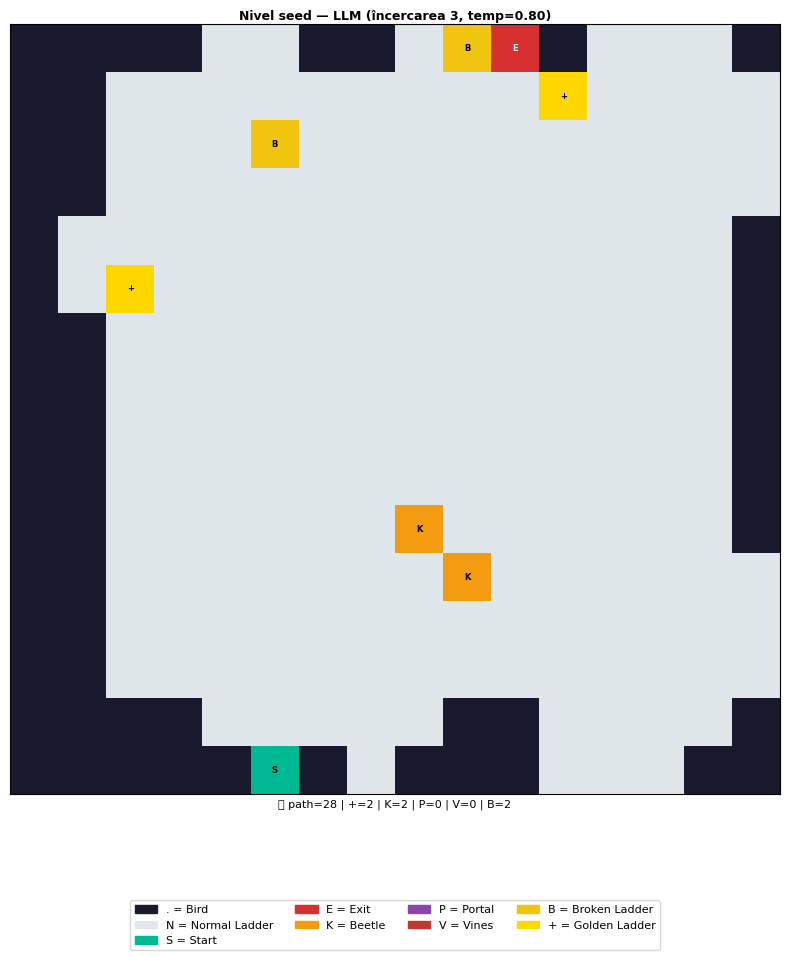

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# vizualizare nivel
def draw_level(ax, g, title='', val=None):
  H, W = len(g), len(g[0])
  img = np.zeros((H, W, 3))

  for r in range(H):
    for c in range(W):
      hx = COLORS.get(g[r][c], '#888')
      img[r, c] = [int(hx[1:3], 16)/255, int(hx[3:5], 16)/255, int(hx[5:7], 16)/255]

  ax.imshow(img, interpolation='nearest', aspect='equal')

  for r in range(H):
    for c in range(W):
      t = g[r][c]
      if t not in (0, 1):
        # text negru pe tile-uri deschise la culoare
        text_color = 'black' if t in (2, 4, 7, 8) else 'white'
        ax.text(c, r, TILE[t][0], ha='center', va='center', fontsize=6,
                      fontweight='bold', color=text_color)

  ax.set_title(title, fontsize=9, fontweight='bold', pad=3)

  if val:
    m = val['metrics']
    ok = '✅' if val['valid'] else '❌'
    stats = (f"{ok} path={m.get('total_path','?')} | "
            f"+={m.get('golden_ladders','?')} | "
            f"K={m.get('beetles','?')} | "
            f"P={m.get('portals','?')} | "
            f"V={m.get('vines','?')} | "
            f"B={m.get('broken_ladders','?')}")
  ax.set_xlabel(stats, fontsize=8)

  ax.set_xticks([])
  ax.set_yticks([])

fig, ax = plt.subplots(figsize=(8, 10))
draw_level(ax, base, f'Nivel seed — {source}', v_final)

patches = [mpatches.Patch(color=COLORS[k], label=f"{TILE[k][0]} = {TILE[k][2]}") for k in sorted(TILE)]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

# **Implementare Algoritmi Genetici**

In [47]:
# definire nivel ușor
def fit_easy(g):
  v = validate(g)
  if not v['valid']:
    return -1000.0

  m = v['metrics']

  return (
      - 1.5 * m.get('total_path', 0)     # Vrem drum relativ compact
      + 30.0 * m.get('golden_ladders', 0) # Recompensa pentru prezența golden ladders
      - 5.0 * m.get('beetles', 0)        # Fara beetles
      - 10.0 * m.get('broken_ladders', 0) # Fara capcane
      - 1.5 * abs(m.get('vines', 0) - 5) # Recompensare vines
      + 2.0 * m.get('birds', 0)
  )

# definire nivel mediu
def fit_medium(g):
  v = validate(g)
  if not v['valid']:
    return -1000.0

  m = v['metrics']

  # Traseu mediu ca lungime, cativa beetles si broken ladders
  return (
      - 2.0 * abs(m.get('total_path', 0) - 35)
      + 25.0 * m.get('golden_ladders', 0)
      - 1.0 * abs(m.get('beetles', 0) - 3)
      - 0.5 * abs(m.get('broken_ladders', 0) - 1)
      + 3.0 * min(m.get('vines', 0), 2)
      + 3.0 * m.get('birds', 0)
  )

# definire nivel greu
def fit_hard(g):
  v = validate(g)
  if not v['valid']:
    return -1000.0

  m = v['metrics']

  # fortam un numar anume de beetles si de broken ladders pentru a nu face
  # nivelul prea dificil, dar incercand sa ii mentinem dificultatea
  return (
      + 3.0 * m.get('total_path', 0)
      + 40.0 * m.get('golden_ladders', 0)
      - 50.0 * abs(m.get('beetles', 0) - 15)
      - 50.0 * abs(m.get('broken_ladders', 0) - 15)
      - 15.0 * m.get('vines', 0)
      + 7.0 * m.get('birds', 0)
  )

FIT = {'easy':fit_easy,'medium':fit_medium,'hard':fit_hard}
def mutate(g, rate=0.05, diff='medium'):
  c = copy.deepcopy(g)
  pool = {
      'easy':   [1, 1, 0, 1, 1, 6],
      'medium': [1, 1, 0, 4, 6, 7],
      'hard':   [1, 0, 0, 4, 0, 7, 0],
  }.get(diff, [1, 1, 1, 6, 7])

  for r in range(1, GRID_H-1):
    for col in range(1, GRID_W-1):
      t = c[r][col]
      if t in (2, 3, 5, 8):
        continue

      if random.random() < rate:
        new_tile = random.choice(pool)

        if new_tile == 1:
          c[r][col] = 1
          continue

        vecini = [c[r-1][col], c[r+1][col], c[r][col-1], c[r][col+1]]

        if new_tile == 6:
          if r >= 2 and (t == 1) and (c[r-2][col] == 1):
            c[r][col] = new_tile


        elif new_tile == 7:
          if (t == 1) and (c[r+1][col] == 1):
            # pentru a nu se pune prea multi broken ladders laolalta
            if 4 not in vecini and 7 not in vecini:
              c[r][col] = new_tile

        elif new_tile == 4:
          if t == 1:
            # pentru a nu se pune prea multe beetles laolalta
            if 4 not in vecini and 7 not in vecini:
              c[r][col] = new_tile

  c = fix_grid(c)
  return c

def crossover(g1,g2):
  p1 = random.randint(1,GRID_H//3)
  p2 = random.randint(GRID_H//3*2,GRID_H-2)
  child = [copy.deepcopy(g1[r]) if r<p1 or r>p2 else copy.deepcopy(g2[r]) for r in range(GRID_H)]
  c = fix_grid(child)
  return c

def tournament(pop,scores,k=3):
  cands=random.sample(list(zip(pop,scores)),min(k,len(pop)))
  return max(cands,key=lambda x:x[1])[0]

def run_ga(seed, diff, pop_size=20, gens=30, elite=3):
  fn = FIT[diff]
  pop = [seed] + [mutate(seed, rate=0.08, diff=diff) for _ in range(pop_size-1)]
  history=[]
  for g in range(gens):
    scores = [fn(ind) for ind in pop]
    history.append(max(scores))
    if g%10 == 0 or g == gens-1:
      valid_n = sum(1 for s in scores if s>-1000)
      print(f'  [{diff}] gen={g:3d} best={max(scores):8.2f} valid={valid_n}/{pop_size}')

    pairs = sorted(zip(scores,pop), key=lambda x:-x[0])
    new = [copy.deepcopy(ind) for _,ind in pairs[:elite]]
    while len(new) < pop_size:
      p1 = tournament(pop, scores)
      child = crossover(p1, tournament(pop,scores)) if random.random()<0.6 else copy.deepcopy(p1)
      new.append(mutate(child,diff=diff))
    pop = new
  final = [fn(ind) for ind in pop]
  best = pop[int(np.argmax(final))]
  return best, history

# testare pe harta generata de llm
ga_results = {}
ga_histories = {}
for diff in['easy', 'medium', 'hard']:
  print(f'\n🧬 GA [{diff.upper()}]')

  best, hist = run_ga(base, diff)
  ga_results[diff] = best
  ga_histories[diff] = hist
  v = validate(best)

  print(f'   ✅ valid={v["valid"]} | {v["metrics"]}')
print('\n🏁 GA complet!')



🧬 GA [EASY]
  [easy] gen=  0 best=  112.50 valid=20/20
  [easy] gen= 10 best=  123.50 valid=20/20
  [easy] gen= 20 best=  125.00 valid=20/20
  [easy] gen= 29 best=  126.50 valid=20/20
   ✅ valid=True | {'beetles': 0, 'portals': 0, 'vines': 5, 'broken_ladders': 1, 'floor': 199, 'golden_ladders': 2, 'total_path': 25, 'birds': 57}

🧬 GA [MEDIUM]
  [medium] gen=  0 best=  211.50 valid=19/20
  [medium] gen= 10 best=  211.50 valid=20/20
  [medium] gen= 20 best=  212.50 valid=20/20
  [medium] gen= 29 best=  212.50 valid=20/20
   ✅ valid=True | {'beetles': 3, 'portals': 0, 'vines': 3, 'broken_ladders': 2, 'floor': 196, 'golden_ladders': 2, 'total_path': 28, 'birds': 57}

🧬 GA [HARD]
  [hard] gen=  0 best= -287.00 valid=19/20
  [hard] gen= 10 best=  541.00 valid=19/20
  [hard] gen= 20 best=  541.00 valid=20/20
  [hard] gen= 29 best=  541.00 valid=19/20
   ✅ valid=True | {'beetles': 15, 'portals': 0, 'vines': 0, 'broken_ladders': 15, 'floor': 188, 'golden_ladders': 2, 'total_path': 30, 'birds':

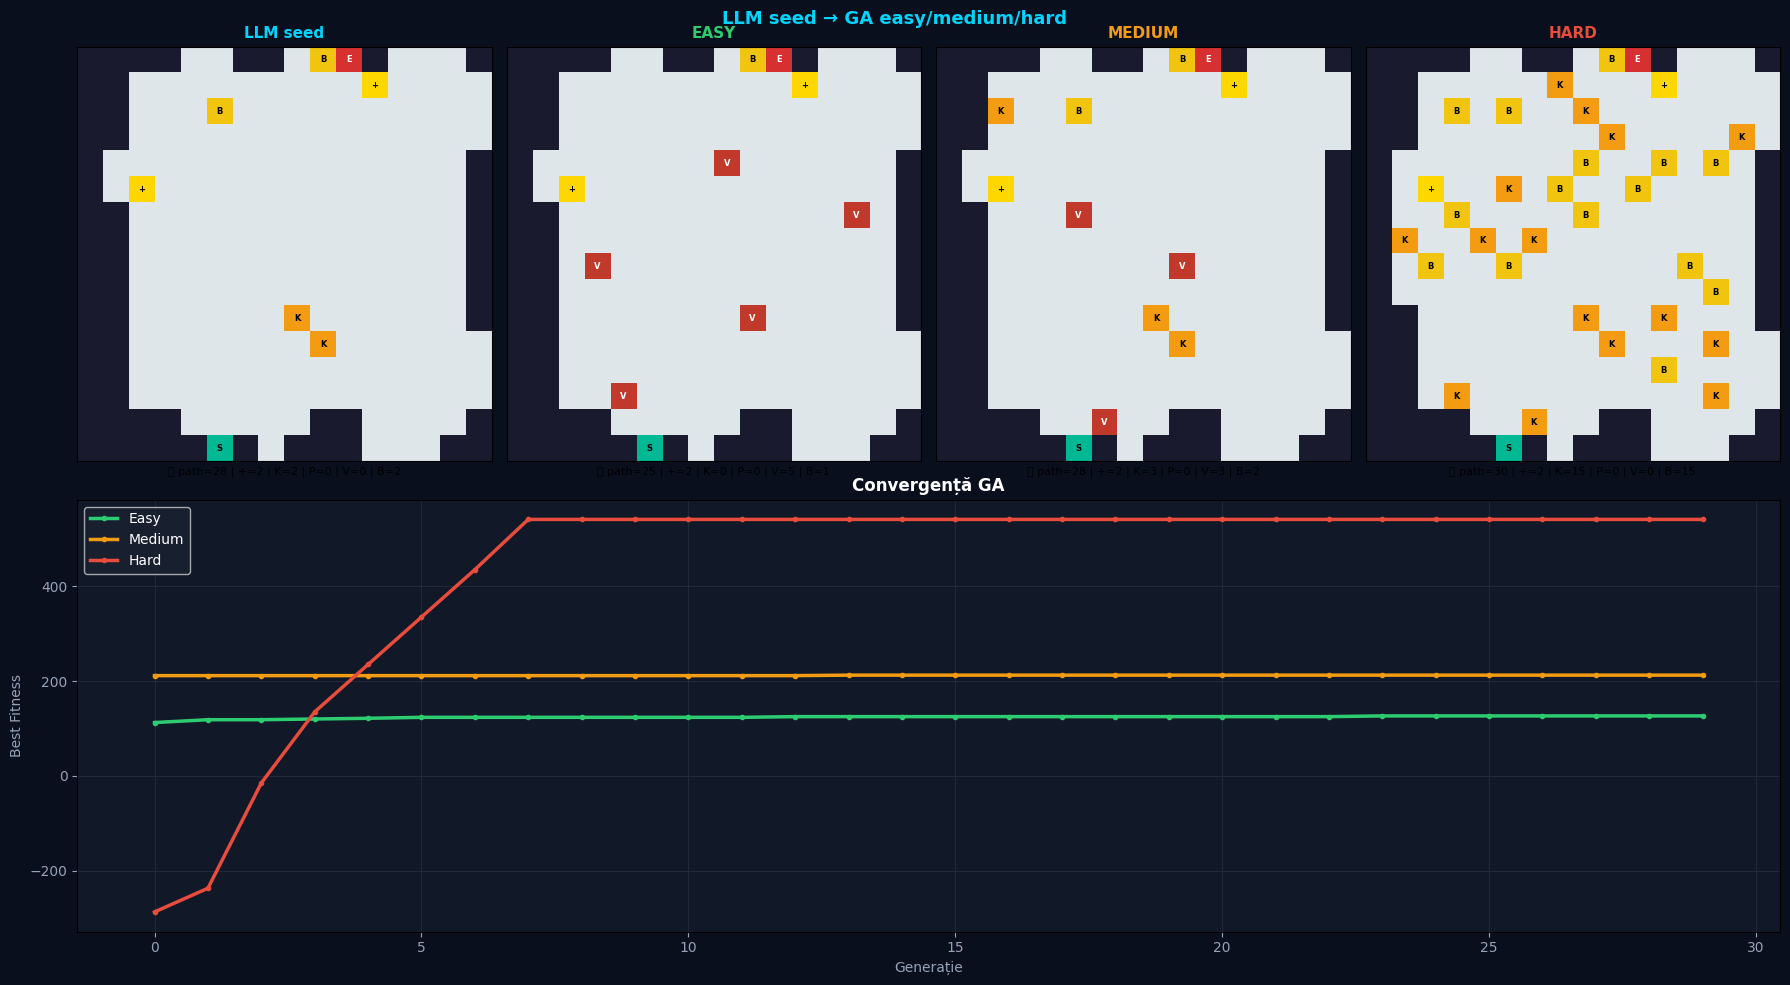

✅ Niveluri selectate pentru Q-Learning:
  easy: valid=True | {'beetles': 0, 'portals': 0, 'vines': 5, 'broken_ladders': 1, 'floor': 199, 'golden_ladders': 2, 'total_path': 25, 'birds': 57}
  medium: valid=True | {'beetles': 3, 'portals': 0, 'vines': 3, 'broken_ladders': 2, 'floor': 196, 'golden_ladders': 2, 'total_path': 28, 'birds': 57}
  hard: valid=True | {'beetles': 15, 'portals': 0, 'vines': 0, 'broken_ladders': 15, 'floor': 188, 'golden_ladders': 2, 'total_path': 30, 'birds': 53}


In [48]:
# vizuarilizare niveluri create
fig = plt.figure(figsize=(18,10))
fig.patch.set_facecolor('#0A0F1E')
DCOL = {'easy':'#2ecc71','medium':'#f39c12','hard':'#e74c3c'}

all_lv = [('LLM seed',base,'#00D4FF')] + [(d.upper(),ga_results[d],DCOL[d]) for d in['easy','medium','hard']]
for i, (lbl,g,col) in enumerate(all_lv):
  ax = fig.add_subplot(2,4,i+1); ax.set_facecolor('#0A0F1E')
  draw_level(ax,g,lbl,validate(g))
  ax.set_title(lbl,color=col,fontsize=11,fontweight='bold')

ax2 = fig.add_subplot(2,4,(5,8))
ax2.set_facecolor('#111827')
for diff,col in DCOL.items():
  ax2.plot(ga_histories[diff],color=col,lw=2.5,label=diff.capitalize(),marker='o',ms=3)

ax2.set_title('Convergență GA',color='white',fontsize=12,fontweight='bold')
ax2.set_xlabel('Generație',color='#94A3B8')
ax2.set_ylabel('Best Fitness',color='#94A3B8')

ax2.legend(fontsize=10,facecolor='#1A2333',labelcolor='white')
ax2.grid(True,color='#1E293B')
ax2.tick_params(colors='#94A3B8')
plt.suptitle('LLM seed → GA easy/medium/hard',color='#00D4FF',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()

ql_levels = {d:ga_results[d] for d in['easy','medium','hard']}
print('✅ Niveluri selectate pentru Q-Learning:')
for d,g in ql_levels.items():
  v = validate(g)
  print(f'  {d}: valid={v["valid"]} | {v["metrics"]}')


# **Q_LEARNING**

In [49]:
import numpy as np
import random

# exit: +100 (cu done=True, doar dacă s-au colectat toate Golden Ladders)
# primul golden ladder: +20 (o singură dată per episod)
# al doilea golden ladder: +10 (o singură dată per episod, dacă există)
# pas normal: -0.1 (time pressure la fiecare mutare)
# celula noua: +0.3 (o singură dată per căsuță nouă explorată)
# bird (zid): -1.0 (agentul rămâne pe loc la lovire)
# beetle: -20.0 (fără done pe nivele grele, pentru a permite explorarea)
# portal (prima utilizare): +5.0 (o singură dată per pereche)
# vine: +1.0 (bonus pentru saltul dublu în sus)
# broken ladder: -2.0 (penalizare pentru căderea forțată în jos)

class TreeClimb:
  ACTIONS = [(-1, 0), (0, 1), (0, -1)]  # UP, RIGHT, LEFT

  def __init__(self, grid, max_steps=300):
    self.grid = grid
    self.max_steps = max_steps
    self.H = len(self.grid)
    self.W = len(self.grid[0])
    self.n_actions = len(self.ACTIONS)

    # 4 stări posibile pentru progresul Golden Ladders (0, 1, 2, 3)
    self.n_states = self.H * self.W * 4

    self.start = find_tile(grid, 2)
    self.exit_pos = find_tile(grid, 3)
    self.portals = find_tiles(grid, 5)
    self.total_checkpoints = find_tiles(grid, 8)

    self.reset()

  def _s(self, r, c):
    pos_id = self.W * r + c
    ck_mask = min(len(self.collected_checkpoints), 3)
    return pos_id * 4 + ck_mask

  def reset(self):
    self.pos = self.start
    self.collected_checkpoints = set()
    self.used_portals = set()
    self.visited_cells = {self.start} if self.start else set()
    self.steps = 0
    return self._s(*self.pos)

  def step(self, action):
    dr, dc = self.ACTIONS[action]
    r, c = self.pos
    self.steps += 1

    nr, nc = r + dr, c + dc

    # definire miscari speciale (vine si broken ladder)
    if 0 <= nr < self.H and 0 <= nc < self.W:
      if self.grid[nr][nc] == 6:
        nr = max(0, nr - 2)
      elif self.grid[nr][nc] == 7:
        nr = min(self.H - 1, nr + 1)

    # lovire de bird
    if not (0 <= nr < self.H and 0 <= nc < self.W) or self.grid[nr][nc] == 0:
      done = self.steps >= self.max_steps
      return self._s(r, c), -1.0, done

    # lovire beetle
    if self.grid[nr][nc] == 4:
      done = self.steps >= self.max_steps
      return self._s(r, c), -10.0, done

    tile = self.grid[nr][nc]

    # teleportare prin portal
    if tile == 5 and len(self.portals) == 2:
      nr, nc = self.portals[1] if (nr, nc) == self.portals[0] else self.portals[0]
      tile = self.grid[nr][nc]

    old_r = self.pos[0]
    self.pos = (nr, nc)
    done = False
    reward = -0.1

    # reward suplimentare pentru inaintare
    # pentru a motiva agentul sa nu renunte
    if nr < old_r:
      reward += 0.2
    elif nr > old_r:
      reward -= 0.2

    # 6. Celulă nouă
    if (nr, nc) not in self.visited_cells:
      reward += 0.3
      self.visited_cells.add((nr, nc))

    # 7. Checkpoints (8)
    if tile == 8 and (nr, nc) not in self.collected_checkpoints:
      self.collected_checkpoints.add((nr, nc))
      reward += 75.0  # Bonus masiv când atinge scara de aur

    elif tile == 5 and (nr, nc) not in self.used_portals:
      self.used_portals.add((nr, nc))
      reward += 5.0

    elif tile == 6:
      reward += 2.0

    elif tile == 7:
      reward -= 2.0

    elif tile == 3:  # EXIT
      if len(self.collected_checkpoints) >= len(self.total_checkpoints):
        reward += 150.0
        done = True
      else:
        # esec daca s-a ajuns la exit fara a fi trecut prin checkpointuri
        reward -= 50.0
        done = True

    if self.steps >= self.max_steps:
      done = True

    return self._s(nr, nc), reward, done

def run_qlearning(env, difficulty='medium', episodes=3500, alpha=0.2, gamma=0.98,
                  epsilon_start=1.0, epsilon_min=0.05, decay=0.995):
  Q = np.zeros((env.n_states, env.n_actions))

  rewards_history = []
  steps_history = []
  success_history = []

  epsilon = epsilon_start

  for ep in range(episodes):
    s = env.reset()
    done = False
    total_reward = 0.0
    step_count = 0

    while not done:
      # Epsilon-Greedy
      if random.random() < epsilon:
        a = random.randint(0, env.n_actions - 1)
      else:
        a = int(np.argmax(Q[s]))

      # Pas în mediu
      next_s, reward, done = env.step(a)
      total_reward += reward
      step_count += 1

      # Ecuația Bellman clasică
      if done:
        td_target = reward
      else:
        td_target = reward + gamma * np.max(Q[next_s])
        td_error = td_target - Q[s, a]
        Q[s, a] += alpha * td_error

    s = next_s

    # Decay la Epsilon
    epsilon = max(epsilon_min, epsilon * decay)

    # Verificare succes complet
    is_success = 1 if (env.pos == env.exit_pos and
                      len(env.collected_checkpoints) >= len(env.total_checkpoints)) else 0

    rewards_history.append(total_reward)
    steps_history.append(step_count)
    success_history.append(is_success)

    if (ep + 1) % 500 == 0:
      recent_win_rate = np.mean(success_history[-100:]) * 100
      print(f"   Episod {ep+1:4d}/{episodes} | Epsilon: {epsilon:.3f} | Win Rate: {recent_win_rate:.1f}%")

  return Q, rewards_history, steps_history, success_history


# bucla de antrenare
ql_Q, ql_rewards, ql_steps, ql_success = {}, {}, {}, {}

for diff in ['easy', 'medium', 'hard']:
    lvl = ga_results[diff]
    v = validate(lvl)

    if not v['valid']:
        print(f'⚠️ [{diff}] invalid → fallback procedural')
        lvl = fallback_level()

    print(f'\n🤖 Q-Learning [{diff.upper()}]')

    env = TreeClimb(lvl, max_steps = 350 if diff == 'hard' else 250)
    Q, rews, stps, succ = run_qlearning(env, difficulty=diff)

    ql_Q[diff], ql_rewards[diff], ql_steps[diff], ql_success[diff] = Q, rews, stps, succ
    print(f'   ✅ Win rate final: {np.mean(succ[-100:])*100:.0f}%')

print('\n🏁 Q-Learning complet!')


🤖 Q-Learning [EASY]


KeyboardInterrupt: 

In [ ]:
# test manual pe nivel easy
# Test manual — urmărește primii 30 de pași pe nivelul easy
env = TreeClimb(ga_results['easy'], max_steps=300)
s = env.reset()

print('Start:', env.start)
print('Exit:', env.exit_pos)
print('Portals:', env.portals)
print('Golden Ladders (Checkpoints):', env.total_checkpoints)
print()

# Mapare caractere pentru TreeClimber
ASC = {0: '#', 1: '.', 2: 'S', 3: 'E', 4: 'K', 5: 'P', 6: 'V', 7: 'B', 8: '+'}

# Actiunile definite în TreeClimb: UP, RIGHT, LEFT
ARR = ['↑', '→', '←']

for step in range(30):
  a = int(np.argmax(ql_Q['easy'][s]))
  old = env.pos
  s, r, done = env.step(a)
  tile = ga_results['easy'][env.pos[0]][env.pos[1]]

  print(f'step={step+1:2d} | {old}→{env.pos} {ARR[a]} | '
        f'tile={ASC.get(tile, "?")} | r={r:+.1f} | '
        f'checkpoints={len(env.collected_checkpoints)}/{len(env.total_checkpoints)}')

  if done:
    print(f'\n🏁 DONE la pasul {step+1} | pos={env.pos} | exit={env.exit_pos}')
    break

In [ ]:
# grafice de antrenare
import matplotlib.pyplot as plt
import numpy as np

def smooth(arr, w=20):
  return np.convolve(arr, np.ones(w) / w, mode='valid')

DCOL = {'easy': '#2ecc71', 'medium': '#f39c12', 'hard': '#e74c3c'}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.patch.set_facecolor('#0A0F1E')

for ri, diff in enumerate(['easy', 'medium', 'hard']):
  col = DCOL[diff]
  rews, stps, succ = ql_rewards[diff], ql_steps[diff], ql_success[diff]

  eps_arr = [max(0.05, 1.0 * (0.998 ** i)) for i in range(len(rews))]

  # 1. Grafic Rewards / episod
  ax = axes[ri][0]
  ax.set_facecolor('#111827')
  ax.plot(rews, color=col, alpha=0.25, lw=0.8)
  if len(rews) >= 20:
    ax.plot(range(19, len(rews)), smooth(rews, 20), color=col, lw=2.5)
  ax.set_title(f'[{diff.upper()}] Reward / ep', color=col, fontsize=10, fontweight='bold')
  ax.set_xlabel('Episod', color='#94A3B8')
  ax.tick_params(colors='#94A3B8')
  ax.grid(True, color='#1E293B')
  ax.spines[:].set_color('#334155')

  # 2. Grafic Win rate (%)
  ax = axes[ri][1]
  ax.set_facecolor('#111827')
  if len(succ) >= 50:
    ws = smooth([s * 100 for s in succ], 50)
    ax.plot(range(49, 49 + len(ws)), ws, color=col, lw=2.5)
  else:
    ax.plot([s * 100 for s in succ], color=col, lw=1.5)
  ax.axhline(50, color='white', lw=1, ls='--', alpha=0.4)
  ax.set_ylim(-5, 105)
  ax.set_title(f'[{diff.upper()}] Win rate (%)', color=col, fontsize=10, fontweight='bold')
  ax.set_xlabel('Episod', color='#94A3B8')
  ax.tick_params(colors='#94A3B8')
  ax.grid(True, color='#1E293B')
  ax.spines[:].set_color('#334155')

  # 3. Grafic Pași + Epsilon
  ax = axes[ri][2]
  ax.set_facecolor('#111827')
  ax.plot(stps, color=col, alpha=0.3, lw=0.8)
  if len(stps) >= 20:
    ax.plot(range(19, len(stps)), smooth(stps, 20), color=col, lw=2.5)

  ax2b = ax.twinx()
  ax2b.plot(eps_arr, color='#74b9ff', lw=1.5, ls='--', alpha=0.7)
  ax2b.set_ylabel('ε (Explorare)', color='#74b9ff', fontsize=8)
  ax2b.tick_params(colors='#74b9ff')

  ax.set_title(f'[{diff.upper()}] Pași + ε', color=col, fontsize=10, fontweight='bold')
  ax.set_xlabel('Episod', color='#94A3B8')
  ax.tick_params(colors='#94A3B8')
  ax.grid(True, color='#1E293B')
  ax.spines[:].set_color('#334155')

plt.suptitle('🤖 Q-Learning Performance — TreeClimber', color='#00D4FF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ql_training.png', dpi=140, bbox_inches='tight', facecolor='#0A0F1E')
plt.show()

In [ ]:
# harta politicii
import matplotlib.pyplot as plt
import numpy as np

def draw_policy(ax, grid, Q, title='', val=None, ck_state=0):
  H, W = len(grid), len(grid[0])
  img = np.zeros((H, W, 3))

  # desenare culoare de fundal
  for r in range(H):
    for c in range(W):
      hx = COLORS.get(grid[r][c], '#888888')
      img[r, c] = [int(hx[1:3], 16) / 255.0, int(hx[3:5], 16) / 255.0, int(hx[5:7], 16) / 255.0]

  ax.imshow(img, interpolation='nearest', aspect='equal', alpha=0.85)

  # definire actiuni din joc
  ARROWS = ['↑', '→', '←']

  # normalizarea culorii sagetii
  qv = []
  for r in range(H):
    for c in range(W):
      if grid[r][c] in PASSABLE:
        st = (r * W + c) * 4 + ck_state
        if st < len(Q):
          qv.append(np.max(Q[st]))

  qmin, qmax = (min(qv), max(qv)) if qv else (0.0, 1.0)

  # suprapunerea sagetii pe casuta
  for r in range(H):
    for c in range(W):
      tile = grid[r][c]
      if tile == 0:
        continue

      st = (r * W + c) * 4 + ck_state
      if st >= len(Q):
        continue

      ba = int(np.argmax(Q[st]))
      qval = np.max(Q[st])

      # gradient: Roșu (valoare Q micăa -> Verde (valoare Q mare)
      norm = np.clip((qval - qmin) / (qmax - qmin + 1e-9), 0.0, 1.0)
      color = (1.0 - norm, norm, 0.2)

      # desenare sageata in directia optima
      if tile not in (0, 3):
        ax.text(c, r, ARROWS[ba], ha='center', va='center', fontsize=8, color=color, fontweight='bold', zorder=5)

      # eticheta text a piesei
      if tile not in (0, 1):
        label = TILE.get(tile, ['?'])[0] if isinstance(TILE.get(tile), (list, tuple)) else str(tile)
        ax.text(c, r - 0.3, label, ha='center', va='center', fontsize=5.5, color='white', fontweight='bold', zorder=6)

  ax.set_title(title, fontsize=10, fontweight='bold', color='white', pad=6)

  if val:
    m = val.get('metrics', {})
    ok = '✅' if val.get('valid', False) else '❌'
    ax.set_xlabel(f"{ok} path={m.get('total_path', '?')} | K={m.get('enemies', '?')} | B={m.get('broken_ladders', '?')}",
                  fontsize=7.5, color='#94A3B8')

  ax.set_xticks([])
  ax.set_yticks([])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0A0F1E')

for i, diff in enumerate(['easy', 'medium', 'hard']):
  lvl = ga_results[diff]
  wr = np.mean(ql_success[diff][-100:]) * 100 if diff in ql_success and len(ql_success[diff]) > 0 else 0

  draw_policy(
        axes[i],
        lvl,
        ql_Q[diff],
        title=f'Politică Q — {diff.upper()} | win={wr:.0f}%',
        val=validate(lvl),
        ck_state=0  # ininate de checkpoints
  )

plt.suptitle('🗺️ Politica Greedy (↑→← = acțiunea optimă | Roșu→Verde = Valoare Q)',
             color='#00D4FF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ql_policy.png', dpi=140, bbox_inches='tight', facecolor='#0A0F1E')
plt.show()

In [ ]:
# rollout greedy
import matplotlib.pyplot as plt
import numpy as np

def run_greedy(grid, Q, max_steps=150, verbose=True):
  env = TreeClimb(grid, max_steps=max_steps)
  s = env.reset()
  path = [env.pos]
  total_r = 0.0
  done = False
  seen_states = {}

  ARROWS = ['↑', '→', '←']
  ASCII_SYM = {0: '#', 1: '.', 2: 'S', 3: 'E', 4: 'K', 5: 'P', 6: 'V', 7: 'B', 8: '+'}

  if verbose:
    print(f'  Start: {env.pos} | Checkpoints de colectat: {len(env.total_checkpoints)}')

  while not done:
    a = int(np.argmax(Q[s]))
    old_pos = env.pos
    s, r, done = env.step(a)
    total_r += r
    path.append(env.pos)

    # detectare bucla infinita
    state_key = (s, len(env.collected_checkpoints))
    seen_states[state_key] = seen_states.get(state_key, 0) + 1
    if seen_states[state_key] > 4:
      if verbose:
        print(f'  ⚠️ Loop detectat la {env.pos} — oprire rollout')
    done = True

    # log periodic la fiecare 20 de pasi
    if verbose and env.steps % 20 == 0:
      tile = grid[env.pos[0]][env.pos[1]]
      print(f'  step={env.steps:3d} | {old_pos}→{env.pos} {ARROWS[a]} '
            f'| tile={ASCII_SYM.get(tile, "?")} '
            f'| r={r:+.1f} | total={total_r:.1f} '
            f'| checkpoints={len(env.collected_checkpoints)}/{len(env.total_checkpoints)}')

    # log pentru evenimente speciale (recompense mari/penalizări)
    if verbose and r not in (-0.1, -1.0, 0.3):
      tile = grid[env.pos[0]][env.pos[1]]
      print(f'  ⭐ step={env.steps:3d} | {ARROWS[a]} → {env.pos} '
            f'| {ASCII_SYM.get(tile, "?")} | r={r:+.1f} | total={total_r:.1f}')

  # verificare victorie structurala
  won = env.pos == env.exit_pos and len(env.collected_checkpoints) >= len(env.total_checkpoints)

  if verbose:
    print(f'  {"✅ CÂȘTIGAT" if won else "❌ EȘUAT"} | '
          f'steps={env.steps} | total_r={total_r:.1f}')

  return path, total_r, env.steps, won


def draw_rollout(ax, grid, path, title=''):
  H, W = len(grid), len(grid[0])
  img = np.zeros((H, W, 3))

  for r in range(H):
    for c in range(W):
      hx = COLORS.get(grid[r][c], '#888888')
      img[r, c] = [int(hx[1:3], 16) / 255.0, int(hx[3:5], 16) / 255.0, int(hx[5:7], 16) / 255.0]

  ax.imshow(img, interpolation='nearest', aspect='equal', alpha=0.75)

  if len(path) > 1:
    for i in range(len(path) - 1):
      t_ = i / max(len(path) - 1, 1)
      line_color = (1.0 - t_, t_, 0.5)

      r_curr, c_curr = path[i]
      r_next, c_next = path[i + 1]

      # identificare celula pe care a pasit agentul
      if c_curr != c_next:
        step_cell = (r_curr, c_next)
      elif r_curr > r_next:
        step_cell = (r_curr - 1, c_curr)
      else:
        step_cell = (r_next, c_next)

      sc_r, sc_c = step_cell

      # verificare daca celula atinsa este liana
      is_vine = (0 <= sc_r < H and 0 <= sc_c < W and grid[sc_r][sc_c] == 6)

      # verificare daca este broken ladder
      is_broken = (0 <= sc_r < H and 0 <= sc_c < W and grid[sc_r][sc_c] == 7 and (r_next - r_curr == 1))

      if is_vine:
        ax.plot([c_curr, sc_c], [r_curr, sc_r], '-', color=line_color, lw=2.5, zorder=4)

        if grid[r_next][c_next] == 6 and r_next != sc_r:
          ax.plot([sc_c, c_next], [sc_r, r_next], '--', color=line_color, lw=2.0, alpha=0.9, zorder=4)
        else:
          ax.plot([sc_c, c_next], [sc_r, r_next], '--', color=line_color, lw=2.0, alpha=0.9, zorder=4)

      elif is_broken:
        ax.plot([c_curr, sc_c], [r_curr, sc_r], '-', color=line_color, lw=2.5, zorder=4)
        ax.plot([sc_c, c_next], [sc_r, r_next], '-', color=line_color, lw=2.5, zorder=4)

      else:
        ax.plot([c_curr, c_next], [r_curr, r_next], '-', color=line_color, lw=2.5, zorder=4)

    cs = [p[1] for p in path]
    rs = [p[0] for p in path]
    ax.plot(cs[0], rs[0], 'o', color='#00ff88', ms=8, zorder=5)
    ax.plot(cs[-1], rs[-1], '*', color='#ff4444', ms=11, zorder=5)
    cs = [p[1] for p in path]
    rs = [p[0] for p in path]
    ax.plot(cs[0], rs[0], 'o', color='#00ff88', ms=8, zorder=5)
    ax.plot(cs[-1], rs[-1], '*', color='#ff4444', ms=11, zorder=5)

  for r in range(H):
    for c in range(W):
      tile = grid[r][c]
      if tile not in (0, 1):
        label = TILE.get(tile, ['?'])[0] if isinstance(TILE.get(tile), (list, tuple)) else str(tile)
        ax.text(c, r, label, ha='center', va='center', fontsize=7, fontweight='bold',
                color='black' if tile in (2, 4, 7, 8) else 'white', zorder=6)

  ax.set_title(title, fontsize=9.5, fontweight='bold', color='white', pad=6)
  ax.set_xticks([])
  ax.set_yticks([])

# rulare si afisare
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0A0F1E')

for i, diff in enumerate(['easy', 'medium', 'hard']):
    print(f'\n{"="*45}')
    print(f'🎮 Rollout [{diff.upper()}]')
    print(f'{"="*45}')

    lvl = ga_results[diff]
    path, total_r, steps, won = run_greedy(lvl, ql_Q[diff], max_steps=150, verbose=True)

    draw_rollout(axes[i], lvl, path,
                 title=f'Rollout {diff.upper()} | r={total_r:.1f} steps={steps} {"✅" if won else "❌"}')

plt.suptitle('🎮 Traseul Agentului Greedy (Verde = Start → Roșu = Final)',
             color='#00D4FF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ql_rollout.png', dpi=140, bbox_inches='tight', facecolor='#0A0F1E')
plt.show()